In [8]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle


In [9]:
Myr_per_Nbody = 0.36627254517014160E+03/ 0.15200000000000000E+03
source = '/cosma5/data/durham/dc-pick2/simulations'
hyades = source + '/Hyades'
hyades

'/cosma5/data/durham/dc-pick2/simulations/Hyades'

In [10]:
path = hyades + '/snap.40_240.h5part'
path

'/cosma5/data/durham/dc-pick2/simulations/Hyades/snap.40_240.h5part'

In [11]:
with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        mtot = np.sum(m)



In [32]:
def get_com(x, y, z, m):
    return [np.sum(m * axis) / np.sum(m) for axis in [x, y, z]]


def shrinking_sphere(x, y, z, m, r=100, rate=0.5, history=None, limit=1000):
    if rate >= 1: return

    count = 0
    
    guess = [np.median(axis)for axis in [x, y, z]]

    bound_x = x.copy()
    bound_y = y.copy()
    bound_z = z.copy()
    bound_m = m.copy()
    
    while True:
        if count > limit: 
            print('limit exceeded')
            return 
        
        if history is not None:
            history.append(guess)
        
        radii = np.sqrt( (bound_x - guess[0])**2 + (bound_y - guess[1])**2 + (bound_z - guess[2])**2 )
        
        idx = radii <= r

        if np.sum(idx) < 0.01 * len(x): return guess

        bound_x = bound_x[idx]
        bound_y = bound_y[idx]
        bound_z = bound_z[idx]
        bound_m = bound_m[idx]

        guess = get_com(bound_x, bound_y, bound_z, bound_m)

        r *= rate
        count += 1
        

    
    

In [33]:
get_com(x, y, z, m)

[np.float32(15.102393), np.float32(-7.5536737), np.float32(0.4713251)]

In [79]:
history = []
com = shrinking_sphere(x, y, z, m, history=history)

history = np.asarray(history)
history

array([[-1032.8811  ,   536.35803 ,    -9.94536 ],
       [-1033.0524  ,   535.5154  ,   -13.261286],
       [-1033.5032  ,   535.4943  ,    -9.828533],
       [-1033.0051  ,   536.4679  ,    -8.941236],
       [-1033.0421  ,   536.53186 ,    -8.952488],
       [-1033.1287  ,   536.5945  ,    -9.108264],
       [-1033.0688  ,   536.5984  ,    -8.964067],
       [-1032.8936  ,   536.6012  ,    -9.063187]], dtype=float32)

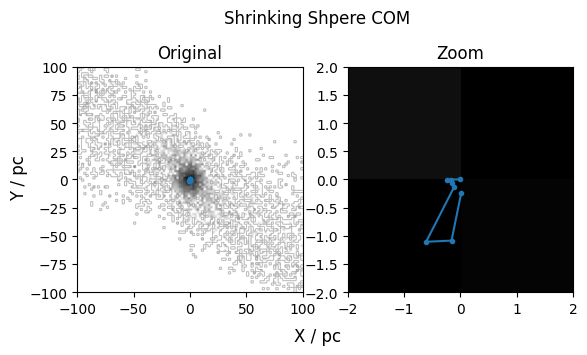

In [78]:
offset = 100
zoom_offset = 2
fig, ax = plt.subplots(1,2)

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[0].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

ax[0].plot(history.T[0] - com[0], history.T[1] - com[1], label='guesses', marker='.')

ax[0].set_xlim(-offset, offset)
ax[0].set_ylim(- offset, offset)
ax[0].set_aspect('equal')
ax[0].set_title('Original')

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax[1].imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

ax[1].plot(history.T[0] - com[0], history.T[1] - com[1], label='guesses', marker='.')

ax[1].set_xlim(-zoom_offset, zoom_offset)
ax[1].set_ylim(- zoom_offset, zoom_offset)
ax[1].set_aspect('equal')
ax[1].set_title('Zoom')

fig.supxlabel('X / pc', y=0.15)
fig.supylabel('Y / pc')

fig.suptitle('Shrinking Shpere COM', y=0.85)

plt.show()

In [38]:
def find_bounding_radii(x, y, z, m, fractions):
    m_tot = np.sum(m)
    com = get_com(x, y, z, m)

    radii = np.sqrt( (x - com[0])**2 + (y - com[1])**2 + (z - com[2])**2 )

    m_fractions = mtot * fractions

    idx = np.argsort(radii)
    radii_sort = radii[idx]
    m_sort = m[idx]
    
    m_cumul = np.cumsum(m_sort)
    
    frac_mass_radii = radii_sort[np.searchsorted(m_cumul, m_fractions)]
    return frac_mass_radii
    



In [39]:
fractions = np.asarray([0.75, 0.5, 0.25])
frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
frac_mass_radii

array([1200.7739, 1181.0881, 1168.0793], dtype=float32)

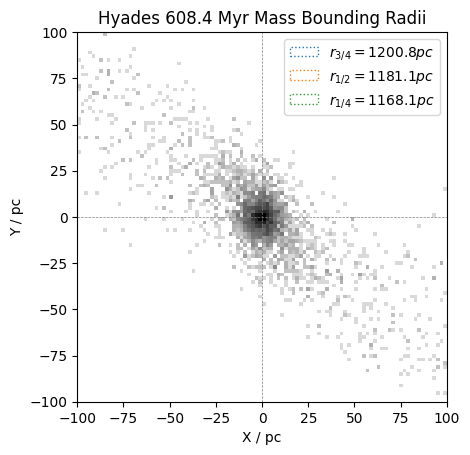

In [40]:
offset = 100
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}={v:.1f}pc$' for l, v in zip(frac_lables, frac_mass_radii)]
          
colours = ['tab:blue', 'tab:orange', 'tab:green']

fig, ax = plt.subplots()

hist, xedges, yedges = np.histogram2d(x - com[0], y - com[1], bins=100, range=[[-offset, offset], [-offset, offset]])
ax.imshow(
hist.T,
origin='lower',
extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
cmap='gray_r',
norm=LogNorm()
)

for r, label, colour in zip(frac_mass_radii, lables, colours):
    r_mass_radius = Circle((0,0), r, fill=False, linestyle='dotted', color=colour, label=label)
    ax.add_artist(r_mass_radius)



ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title(f'Hyades {t:.1f} Myr Mass Bounding Radii')
ax.set_xlabel('X / pc')
ax.set_ylabel('Y / pc')
ax.set_xlim(-offset, offset)
ax.set_ylim(- offset, offset)
ax.set_aspect('equal')
plt.legend()

plt.show()


In [ ]:
fractions = np.asarray([0.75, 0.5, 0.25])
results = []
times = []

for snap in [0, 60, 120, 180, 240]:
    path = hyades + f'/snap.40_{snap}.h5part'

    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        frac_mass_radii = find_bounding_radii(x, y, z, m, fractions)
        results.append(frac_mass_radii)
        times.append(t)

    
results = np.asarray(results)
times = np.asarray(times)




In [ ]:
frac_lables = ['3/4', '1/2', '1/4']
lables = [fr'$r_{{{l}}}$' for l in frac_lables]

fig, ax = plt.subplots()

for i, (label, colour) in enumerate(zip(lables, colours)):
    ax.plot(times, results.T[i], label=label, color=colour, marker='.')

ax.set_xlabel('time / Myrs')
ax.set_ylabel('radius / pc')

#ax.set_yscale('log')

plt.title("Hyades Bounding Radii Expansion")
plt.legend()
plt.show()
 

In [ ]:
results.T[0]

In [ ]:
def find_mass_profile(x, y, z, m):
    com = get_com(x, y, z, m)

    radii = np.sqrt( (x - com[0])**2 + (y - com[1])**2 + (z - com[2])**2 )

    idx = np.argsort(radii)
    radii_sort = radii[idx]
    m_sort = m[idx]
    
    return radii_sort, m_sort, np.cumsum(m_sort)



In [ ]:
fractions = np.asarray([0.75, 0.5, 0.25])
radiis = []
masses = []
times = []

for snap in [0, 60, 120, 180, 240]:
    path = hyades + f'/snap.40_{snap}.h5part'

    with h5py.File(path, 'r') as f:
        last_step = list(f.keys())[-1]
        x = f[last_step]['X1'][:]
        y = f[last_step]['X2'][:]
        z = f[last_step]['X3'][:]
        m = f[last_step]['M'][:]
        t = f[last_step].attrs['Time'] * Myr_per_Nbody

        r_sort, m_sort, m_sums = find_mass_profile(x, y, z, m)
        masses.append(m_sums)
        radiis.append(r_sort)
        times.append(t)

In [ ]:
for r_sort, m_sums, t in zip(radiis, masses, times):
    plt.plot(r_sort, m_sums, label=f'{t:.1f}Myr')
    
plt.xscale('log')
#plt.yscale('log')

plt.legend()
plt.xlabel(r'$r$ / $pc$')
plt.ylabel(r'$M(<r)$ / $M_\odot$')
plt.title('Hyades Mass Profile Evolution')
plt.show()